# PCA con Prince: Analisis completo

Este notebook implementa un flujo estructurado de PCA con `prince` e incluye:

1. Plano principal (individuos)
2. Circulo de correlaciones
3. Varianza explicada (barras + acumulada)
4. Grafico de sobreposicion (biplot)
5. Contribucion de variables
6. Cosenos al cuadrado (`cos2`)

> Puedes reemplazar el dataset por uno propio manteniendo la misma estructura.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_blobs

from scripts.data_prep import standardize_features
from scripts.pca_model import fit_prince_pca, extract_pca_results
from scripts.plot_plano_principal import plot_plano_principal
from scripts.plot_correlacion import plot_circulo_correlaciones
from scripts.plot_varianza import plot_varianza_explicada
from scripts.plot_sobreposicion import plot_biplot_sobreposicion
from scripts.metrics_contrib_cos2 import (
    compute_contribuciones,
    plot_contribuciones_pc1_pc2,
    compute_cos2_variables,
    plot_heatmap_cos2,
)

sns.set(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

## 1) Carga y preparacion de datos

Usamos un dataset de **clientes** (segmentacion comercial) con **8 variables** de comportamiento.

In [2]:
# Dataset de clientes (simulado, estilo negocio)
# 8 variables numericas para analisis de segmentacion
X_base, clusters = make_blobs(
    n_samples=600,
    n_features=8,
    centers=3,
    cluster_std=1.8,
    random_state=42,
)

feature_cols = [
    "edad",
    "ingreso_mensual",
    "antiguedad_meses",
    "recencia_dias",
    "frecuencia_compra",
    "ticket_promedio",
    "uso_digital",
    "satisfaccion",
]

df = pd.DataFrame(X_base, columns=feature_cols)

# Escalamos cada variable para que parezcan metricas de negocio realistas
scales = np.array([12, 2200, 18, 25, 7, 120, 15, 10])
shifts = np.array([40, 4500, 36, 30, 8, 180, 55, 70])
df[feature_cols] = df[feature_cols] * scales + shifts

# Etiqueta de segmento de cliente (solo para colorear graficos)
segment_names = {0: "Segmento A", 1: "Segmento B", 2: "Segmento C"}
df["segmento_cliente"] = pd.Series(clusters).map(segment_names)
y = df["segmento_cliente"].copy()

# Estandarizacion (modulo reutilizable)
X_scaled_df, scaler = standardize_features(df, feature_cols)

print("Dimensiones de X:", X_scaled_df.shape)
print("Variables usadas:", list(feature_cols))
X_scaled_df.head()

Dimensiones de X: (600, 8)
Variables usadas: ['edad', 'ingreso_mensual', 'antiguedad_meses', 'recencia_dias', 'frecuencia_compra', 'ticket_promedio', 'uso_digital', 'satisfaccion']


,edad,ingreso_mensual,antiguedad_meses,recencia_dias,frecuencia_compra,ticket_promedio,uso_digital,satisfaccion
0,-0.406353,-0.932787,0.261001,-1.326530,-0.240973,0.144811,-0.531801,-0.433501
1,1.292114,0.217271,-1.596144,1.701507,1.080619,1.893539,-0.456315,-0.403624
2,-1.148079,-1.122821,0.094957,-1.153619,0.283859,-1.266317,0.439876,-0.715284
3,1.737528,-0.264194,-1.723975,0.897118,1.497386,0.173818,-0.102939,-1.020630
4,-1.779539,-1.118191,0.476800,-1.596478,-0.055345,-0.195357,0.246724,-0.571932


## 2) Ajuste del modelo PCA con Prince

In [3]:
pca = fit_prince_pca(X_scaled_df, n_components=4, random_state=42)
results = extract_pca_results(pca, X_scaled_df)

row_coords = results["row_coords"]
col_corr = results["col_corr"]
eigenvalues = results["eigenvalues"]
explained = results["explained"]
cumulative = results["cumulative"]
variance_df = results["variance_df"]

variance_df

,Componente,Eigenvalor,% Varianza,% Acumulado
0,PC1,3.881910,48.523869,48.523869
1,PC2,2.347616,29.345197,77.869065
2,PC3,0.775729,9.696608,87.565674
3,PC4,0.416935,5.211682,92.777356


In [4]:
explained

array([48.52386876, 29.34519669,  9.69660841,  5.21168221])

## 3) Plano principal (PC1 vs PC2)

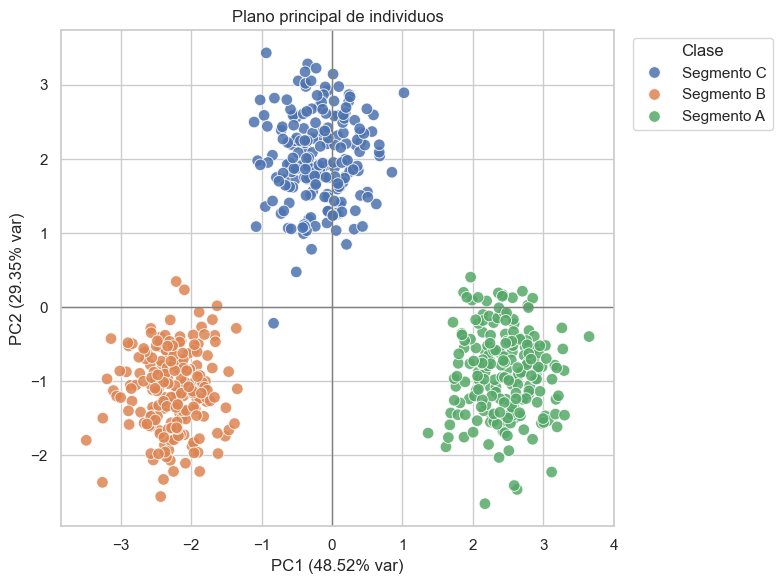

In [4]:
plot_plano_principal(row_coords, y, explained)

## 4) Grafico de correlacion (circulo de correlaciones)

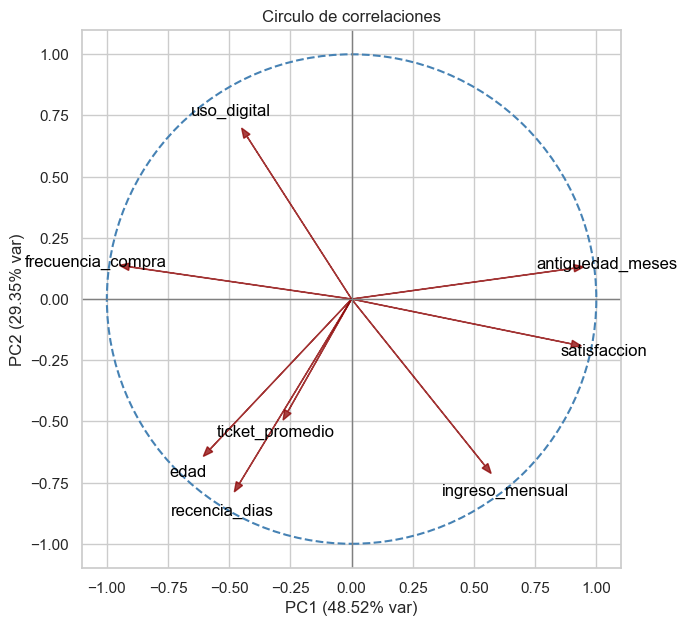

In [5]:
plot_circulo_correlaciones(col_corr, explained)

## 5) Varianza explicada (barras + acumulada)

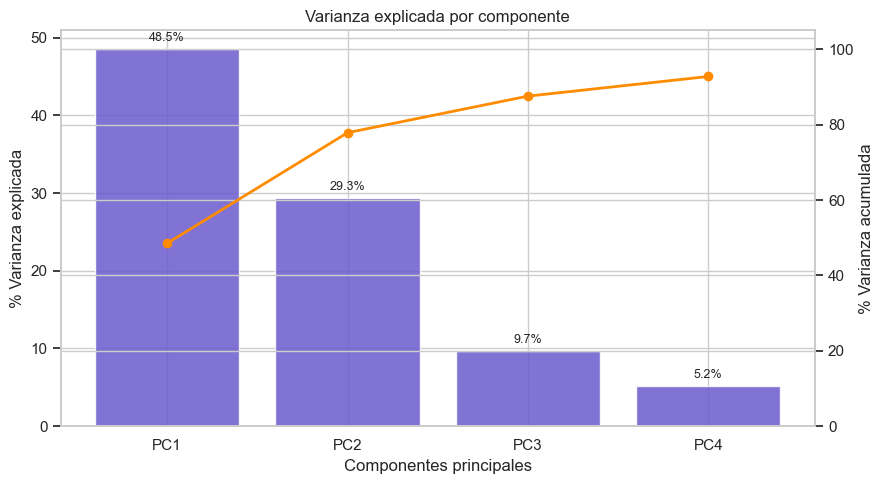

,Componente,Eigenvalor,% Varianza,% Acumulado
0,PC1,3.881910,48.523869,48.523869
1,PC2,2.347616,29.345197,77.869065
2,PC3,0.775729,9.696608,87.565674
3,PC4,0.416935,5.211682,92.777356


In [6]:
plot_varianza_explicada(explained, cumulative)
variance_df

## 6) Grafico de sobreposicion (biplot)

Se combinan los individuos (scores) y las variables (loadings/correlaciones).

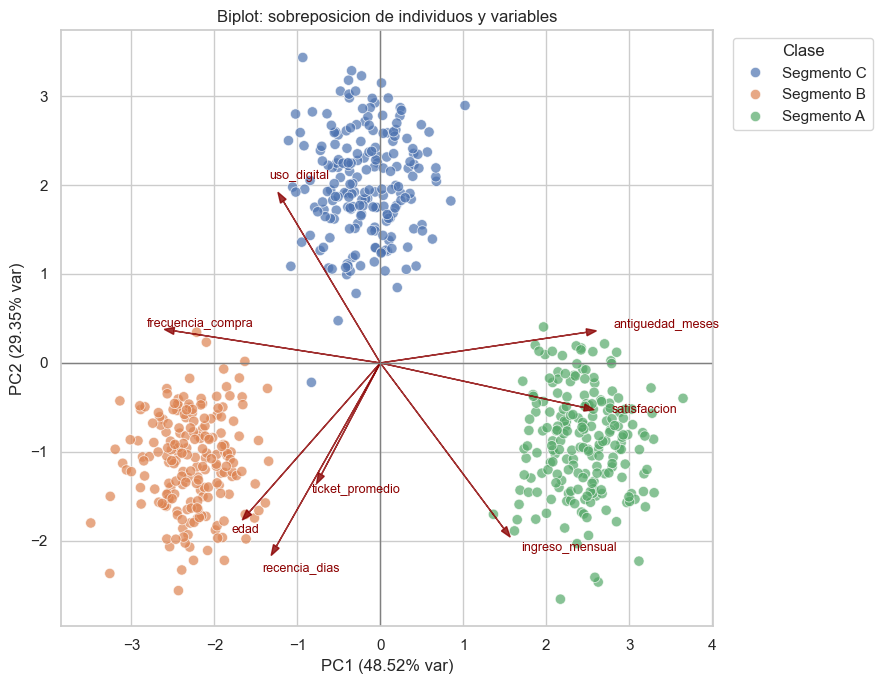

In [7]:
plot_biplot_sobreposicion(row_coords, col_corr, y, explained)

## 7) Contribucion de las variables

Aproximacion clasica: `contribucion_{j,k} = (corr_{j,k}^2 / eigenvalor_k) * 100`.

In [8]:
contrib = compute_contribuciones(col_corr, eigenvalues)
contrib

,PC1,PC2,PC3,PC4
variable,,,,
edad,9.455,17.604,5.954,3.342
ingreso_mensual,8.377,21.632,1.319,14.934
antiguedad_meses,23.180,0.737,0.462,0.746
recencia_dias,5.915,26.452,4.207,3.345
frecuencia_compra,23.168,0.806,0.120,2.180
ticket_promedio,2.020,10.419,87.096,0.150
uso_digital,5.201,20.789,0.781,72.741
satisfaccion,22.684,1.560,0.061,2.562


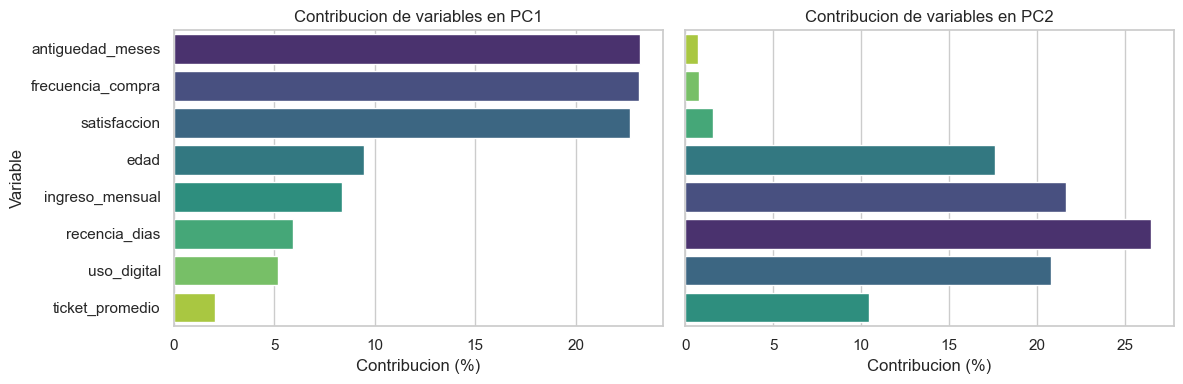

In [9]:
plot_contribuciones_pc1_pc2(contrib)

## 8) Cosenos al cuadrado (cos2) de variables

Para variables, `cos2` se obtiene como la correlacion al cuadrado con cada componente.

In [10]:
cos2_vars = compute_cos2_variables(col_corr)
cos2_vars

,PC1,PC2,PC3,PC4
variable,,,,
edad,0.3670,0.4133,0.0462,0.0139
ingreso_mensual,0.3252,0.5078,0.0102,0.0623
antiguedad_meses,0.8998,0.0173,0.0036,0.0031
recencia_dias,0.2296,0.6210,0.0326,0.0139
frecuencia_compra,0.8994,0.0189,0.0009,0.0091
ticket_promedio,0.0784,0.2446,0.6756,0.0006
uso_digital,0.2019,0.4880,0.0061,0.3033
satisfaccion,0.8806,0.0366,0.0005,0.0107


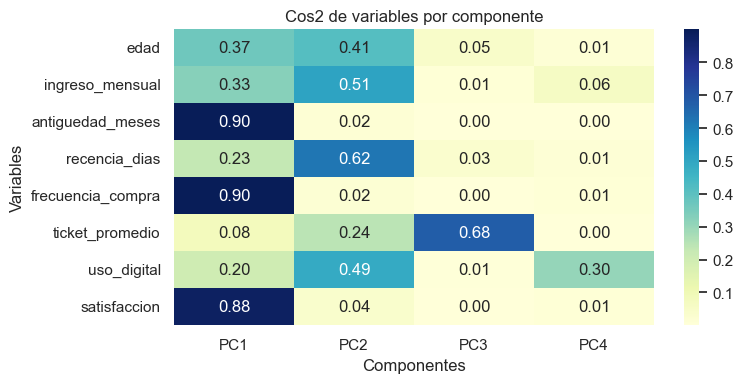

In [11]:
plot_heatmap_cos2(cos2_vars)

## 9) Interpretacion rapida

- Componentes con mayor `% Varianza` resumen mejor la informacion.
- En el circulo de correlaciones, vectores largos indican mejor representacion por PC1-PC2.
- En contribuciones, variables con mayor `%` son mas influyentes en cada componente.
- En `cos2`, valores altos indican buena calidad de representacion en ese eje.